In [1]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,7


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
 18  Order Ye

In [4]:
df.isnull().sum()



Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Order Year        0
Order Month       0
Shipping Days     0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(0)

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Order Year,Order Month,Shipping Days
count,9800.000000,9789.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,55273.322403,230.769059,2016.724184,7.818469,3.961122
std,2829.160653,32041.223413,626.651875,1.123984,3.281905,1.749614
min,1.000000,1040.000000,0.444000,2015.000000,1.000000,0.000000
25%,2450.750000,23223.000000,17.248000,2016.000000,5.000000,3.000000
50%,4900.500000,58103.000000,54.490000,2017.000000,9.000000,4.000000
75%,7350.250000,90008.000000,210.605000,2018.000000,11.000000,5.000000
max,9800.000000,99301.000000,22638.480000,2018.000000,12.000000,7.000000


In [7]:
# data is clean.

# monthly sales

In [8]:
monthly_sales = df.groupby(["Order Year", "Order Month"])["Sales"].sum().reset_index()
monthly_sales.head()

,Order Year,Order Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


# Observation:

Sales fluctuate monthly.

Certain months show noticeable peaks.

Interpretation:
Seasonality exists in purchasing behavior.

Business Insight:
Promotional campaigns can be aligned with high-performing months.

# Sales by Region

In [9]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

# Sales by Category

In [10]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

# Observation:

Technology category generates the highest revenue.

Furniture and Office Supplies follow.

Interpretation:
Technology products drive significant revenue contribution.

Business Insight:
Focus on expanding technology product lines and optimizing inventory.

# Top 10 Customers

In [11]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

# Shipping Performance

In [12]:
shipping_analysis = df.groupby("Ship Mode")["Shipping Days"].mean()
shipping_analysis

Ship Mode
First Class       2.179214
Same Day          0.044610
Second Class      3.249211
Standard Class    5.008363
Name: Shipping Days, dtype: float64

# Observation:

Average shipping days vary across ship modes.

Standard Class takes longest time.

Interpretation:
Faster shipping modes could improve customer satisfaction.

Business Insight:
Encourage customers to opt for faster shipping for improved service quality.

# Visualization

# 1. Sales Distribution

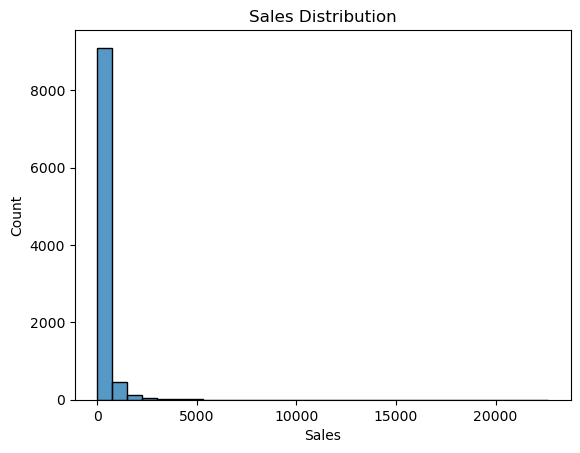

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.show()

# Observation:

Sales distribution is right-skewed.

Majority of transactions have low sales value.

Few transactions have very high sales (outliers).

Interpretation:
This indicates that most orders are small-value purchases, while a small number of large transactions significantly contribute to revenue.

Business Insight:
High-value customers should be identified and targeted with loyalty programs to maximize revenue retention.

# Sales by Region

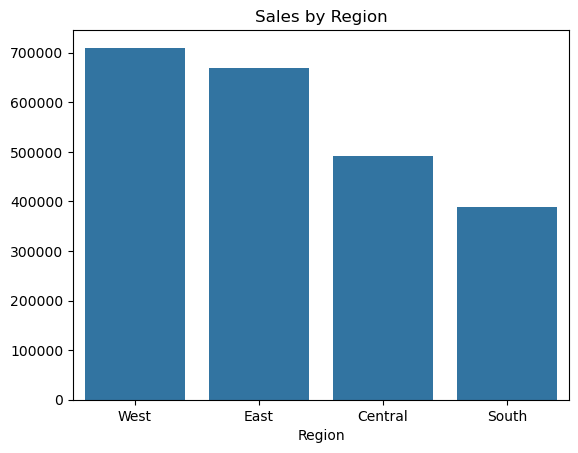

In [18]:
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.show()

# Observation:

West region generates the highest revenue.

South region shows comparatively lower sales.

Interpretation:
Market performance varies geographically.

Business Insight:
The company can investigate why South region underperforms and allocate marketing efforts accordingly.

# Correlation analysis

In [19]:
df.corr(numeric_only=True)

,Row ID,Postal Code,Sales,Order Year,Order Month,Shipping Days
Row ID,1.000000,0.013645,0.001151,0.019065,-0.014809,0.000976
Postal Code,0.013645,1.000000,-0.024067,0.006418,0.021685,-0.009443
Sales,0.001151,-0.024067,1.000000,-0.010624,-0.000134,-0.005712
Order Year,0.019065,0.006418,-0.010624,1.000000,-0.018278,-0.024498
Order Month,-0.014809,0.021685,-0.000134,-0.018278,1.000000,0.000210
Shipping Days,0.000976,-0.009443,-0.005712,-0.024498,0.000210,1.000000


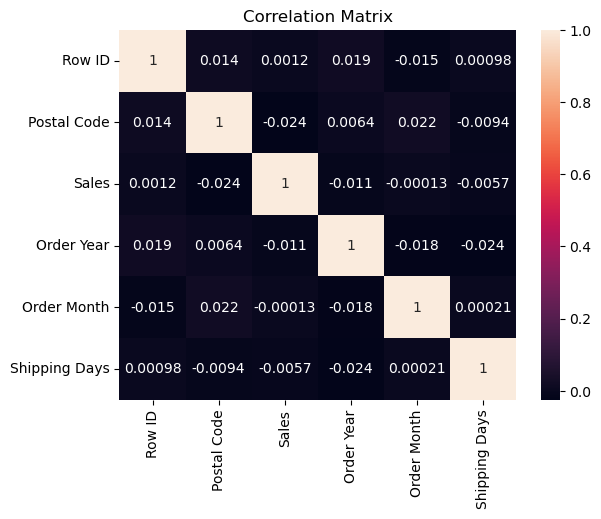

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()